In [49]:
import pandas as pd
import numpy as np

In [50]:
event = pd.read_csv('../data/raw/holidays_events.csv')

In [51]:
event.isnull().sum()

date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64

In [52]:
oil = pd.read_csv('../data/raw/oil.csv')
oil.isnull().sum()

date           0
dcoilwtico    43
dtype: int64

In [53]:
items = pd.read_csv('../data/raw/items.csv')
items.isnull().sum()

item_nbr      0
family        0
class         0
perishable    0
dtype: int64

In [54]:
submission = pd.read_csv('../data/raw/sample_submission.csv')
submission.isnull().sum()

id            0
unit_sales    0
dtype: int64

In [55]:
stores = pd.read_csv('../data/raw/stores.csv')
stores.isnull().sum()

store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64

In [56]:
transaction = pd.read_csv(r'E:\nic\SIC-AI-PROJECT-\data\raw\transactions.csv')
transaction.isnull().sum()

date            0
store_nbr       0
transactions    0
dtype: int64

In [57]:
train = pd.read_parquet('../data/processed/train_merged.parquet')

In [58]:
train.head()

,store_nbr,family,date,unit_sales,onpromotion,oil_price,is_earthquake_period,holiday_type,city,state,type,cluster,transactions_lag1,target
0,1,AUTOMOTIVE,2016-01-02,7.0,False,36.81,False,Normal Day,Quito,Pichincha,D,13,NaN,7.0
1,1,AUTOMOTIVE,2016-01-03,1.0,False,36.81,False,Normal Day,Quito,Pichincha,D,13,NaN,1.0
2,1,AUTOMOTIVE,2016-01-04,8.0,False,36.81,False,Normal Day,Quito,Pichincha,D,13,2025.0,8.0
3,1,AUTOMOTIVE,2016-01-05,7.0,False,35.97,False,Normal Day,Quito,Pichincha,D,13,10.0,7.0
4,1,AUTOMOTIVE,2016-01-06,9.0,False,33.97,False,Normal Day,Quito,Pichincha,D,13,1840.0,9.0


In [59]:
train.columns

Index(['store_nbr', 'family', 'date', 'unit_sales', 'onpromotion', 'oil_price',
       'is_earthquake_period', 'holiday_type', 'city', 'state', 'type',
       'cluster', 'transactions_lag1', 'target'],
      dtype='object')

store_nbr: Mã số định danh cửa hàng (Store Number).

family: Danh mục/Dòng sản phẩm (ví dụ: GROCERY, BEVERAGES, PRODUCE...).

date: Ngày ghi nhận dữ liệu giao dịch.

unit_sales: Tổng số lượng sản phẩm bán ra thực tế trong ngày.

onpromotion: Cột đánh dấu trạng thái khuyến mãi (1: đang có khuyến mãi, 0: không có).

oil_price: Giá dầu thô trong ngày (yếu tố kinh tế vĩ mô ảnh hưởng đến sức mua tại Ecuador).

is_earthquake_period: Cột biến phụ (Flag feature) đánh dấu giai đoạn chịu ảnh hưởng bởi trận động đất lớn tại Ecuador năm 2016 (1: giai đoạn động đất, 0: bình thường).

holiday_type: Phân loại ngày lễ/sự kiện trong ngày (ví dụ: Holiday, Event, Transfer, Normal).

city: Thành phố nơi đặt cửa hàng.

state: Bang/Tỉnh nơi đặt cửa hàng.

type: Loại quy mô cửa hàng (phân loại từ A đến E).

cluster: Mã nhóm các cửa hàng có đặc điểm doanh số/hành vi tiêu dùng tương đồng.

transactions_lag1: Tổng số lượt giao dịch (hóa đơn) của cửa hàng đó ở 1 ngày trước đó (Lag 1 feature được tạo ra để dự báo).

target: Biến mục tiêu để đưa vào mô hình huấn luyện (thường là np.log1p(unit_sales) đã qua xử lý logarit để tính điểm NWRMSLE).

In [60]:
train.isnull().sum()

store_nbr                  0
family                     0
date                       0
unit_sales                 0
onpromotion                0
oil_price                  0
is_earthquake_period       0
holiday_type               0
city                       0
state                      0
type                       0
cluster                    0
transactions_lag1       3162
target                     0
dtype: int64

In [61]:
from sklearn.impute import SimpleImputer

# 1. Khởi tạo imputer với strategy='constant' và fill_value=0
imputer = SimpleImputer(strategy='constant', fill_value=0)

# 2. Transform cột dữ liệu (cần truyền dạng 2D dataframe [[...]])
train['transactions_lag1'] = imputer.fit_transform(train[['transactions_lag1']])

In [62]:
train.isnull().sum()

store_nbr               0
family                  0
date                    0
unit_sales              0
onpromotion             0
oil_price               0
is_earthquake_period    0
holiday_type            0
city                    0
state                   0
type                    0
cluster                 0
transactions_lag1       0
target                  0
dtype: int64

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
train.describe()

,store_nbr,date,unit_sales,oil_price,cluster,transactions_lag1,target
count,874052.000000,874052,874052.000000,874052.000000,874052.000000,874052.000000,874052.000000
mean,27.239577,2016-10-26 06:33:13.408172032,552.427734,45.671888,8.486566,1688.029835,552.452087
min,1.000000,2016-01-01 00:00:00,-6663.000000,26.190000,1.000000,0.000000,0.000000
25%,13.000000,2016-05-30 00:00:00,9.000000,43.410000,4.000000,1042.000000,9.000000
50%,27.000000,2016-10-28 00:00:00,61.221500,47.020000,8.000000,1389.000000,61.221500
75%,41.000000,2017-03-26 00:00:00,370.499504,49.760000,13.000000,2048.000000,370.499504
max,54.000000,2017-08-15 00:00:00,124717.000000,54.480000,17.000000,8307.000000,124717.000000
std,15.644502,NaN,1428.538208,6.366444,4.634879,962.864967,1428.492310


In [65]:
train_or = pd.read_csv('../data/raw/train.csv')
print(len(train), len(train_or))  # phải bằng nhau nếu join đúng

KeyboardInterrupt: 

In [ ]:
train[train['unit_sales'] < -1000]

In [66]:
neg_extreme = train[train['unit_sales'] < -1000]
cluster_check = neg_extreme.groupby(['store_nbr', 'date']).size().sort_values(ascending=False)
print(cluster_check.head(10))


store_nbr  date      
53         2016-05-14    3
2          2016-05-07    1
8          2016-04-21    1
29         2016-05-16    1
38         2016-12-20    1
dtype: int64


In [67]:
train['date'].dtype

dtype('<M8[ns]')

In [69]:
train.isnull().sum()

store_nbr               0
family                  0
date                    0
unit_sales              0
onpromotion             0
oil_price               0
is_earthquake_period    0
holiday_type            0
city                    0
state                   0
type                    0
cluster                 0
transactions_lag1       0
target                  0
dtype: int64

In [ ]:
test_original = pd.read_csv('../data/raw/test.csv')

In [ ]:
test_original.head()

In [ ]:
test_original['date'].max()

In [ ]:
train[train['date'] == '2017-04-06']

In [ ]:
train[train['date'] == '2017-04-06'].groupby('store_nbr')['unit_sales'].sum()

In [ ]:
day_data = train[train['date'] == '2017-04-06']

total_with_outlier = day_data['unit_sales'].sum()
total_without_outlier = day_data[day_data['unit_sales'] != -10002]['unit_sales'].sum()

print(f"Có outlier: {total_with_outlier}")
print(f"Không có outlier: {total_without_outlier}")
print(f"Chênh lệch: {total_without_outlier - total_with_outlier}")

# xóa hàng 45147165	

In [ ]:
store32_day = train[(train['date']=='2016-12-20') & (train['store_nbr']==32)]

total_store_with = store32_day['unit_sales'].sum()
total_store_without = store32_day[store32_day['unit_sales'] != -3451.363037]['unit_sales'].sum()

print(f"Cửa hàng 32, có outlier: {total_store_with}")
print(f"Cửa hàng 32, không có: {total_store_without}")
print(f"Tỷ lệ ảnh hưởng: {-3451.363037 / total_store_without * 100:.1f}%")

<Axes: xlabel='holiday_type', ylabel='unit_sales'>

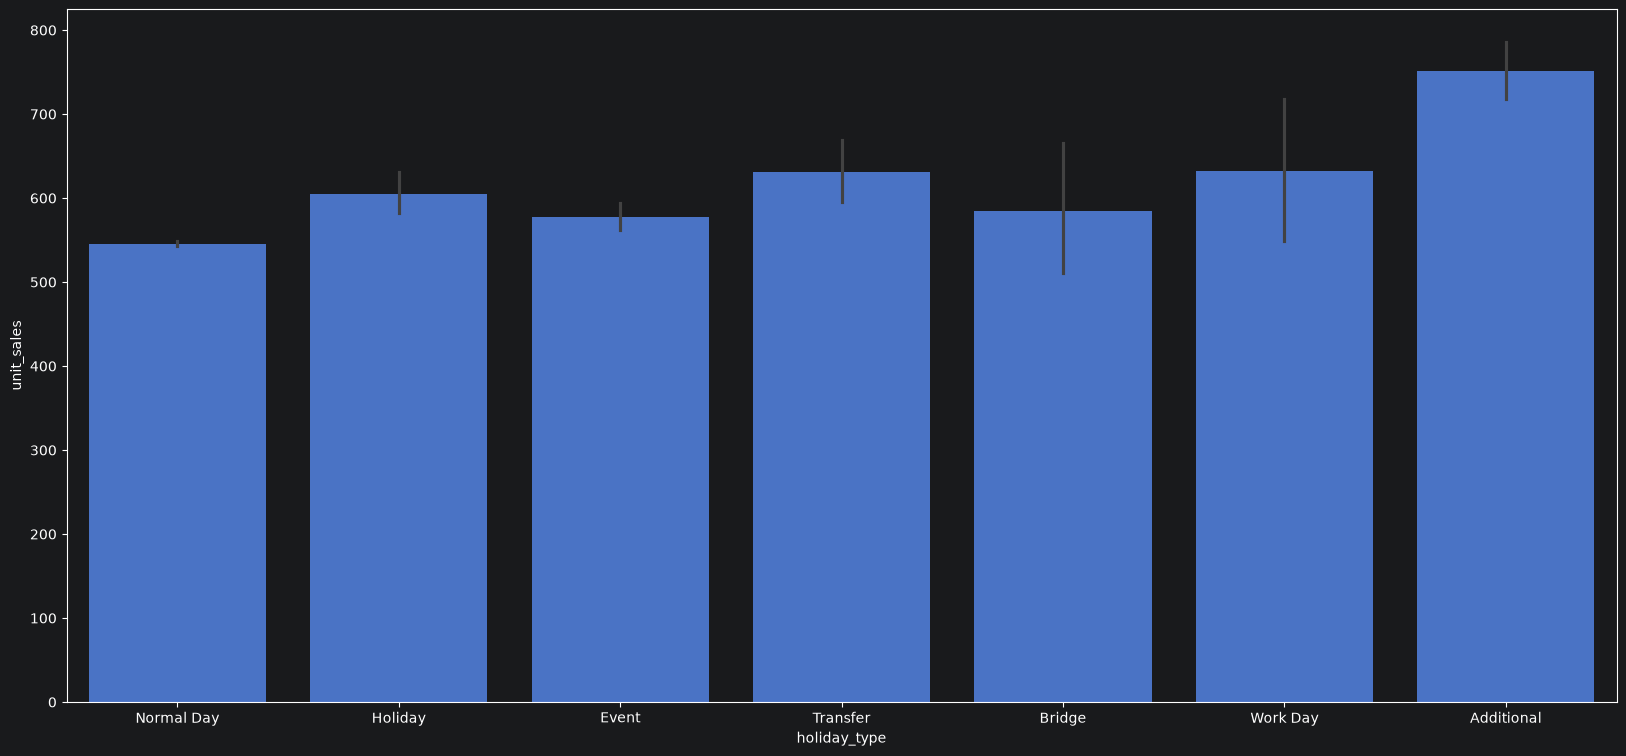

In [70]:
plt.figure(figsize=(20,9))
sns.barplot(data=train, x = 'holiday_type', y= 'unit_sales')

<Axes: xlabel='family', ylabel='unit_sales'>

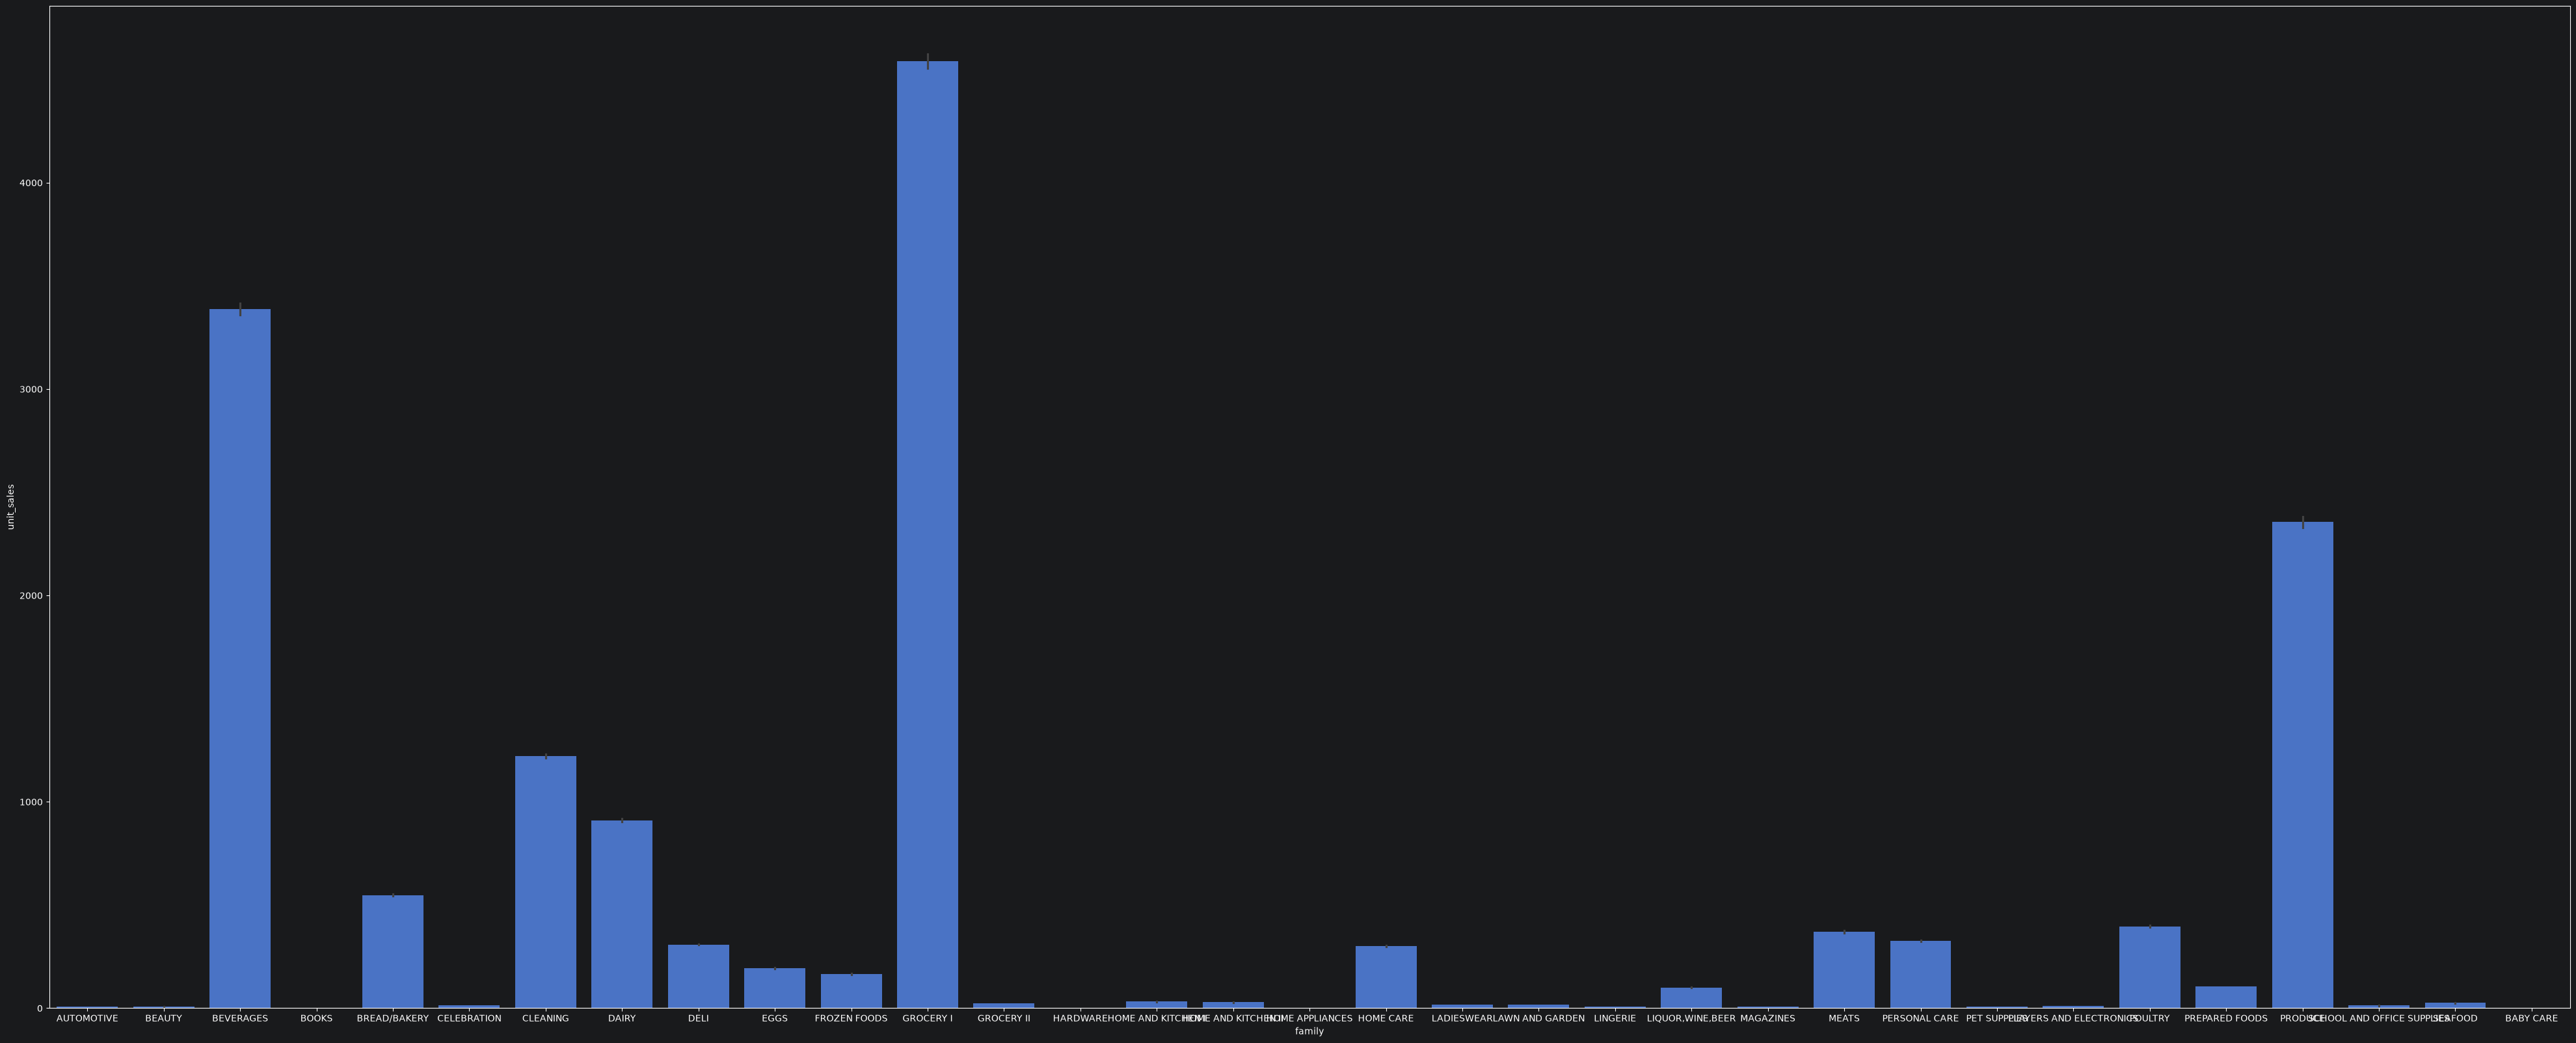

In [79]:
plt.figure(figsize=(50,20))
sns.barplot(data=train, x = 'family', y= 'unit_sales')

In [76]:
train.family.unique()

array(['AUTOMOTIVE', 'BEAUTY', 'BEVERAGES', 'BOOKS', 'BREAD/BAKERY',
       'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS', 'FROZEN FOODS',
       'GROCERY I', 'GROCERY II', 'HARDWARE', 'HOME AND KITCHEN I',
       'HOME AND KITCHEN II', 'HOME APPLIANCES', 'HOME CARE',
       'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE', 'LIQUOR,WINE,BEER',
       'MAGAZINES', 'MEATS', 'PERSONAL CARE', 'PET SUPPLIES',
       'PLAYERS AND ELECTRONICS', 'POULTRY', 'PREPARED FOODS', 'PRODUCE',
       'SCHOOL AND OFFICE SUPPLIES', 'SEAFOOD', 'BABY CARE'], dtype=object)

In [68]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 874052 entries, 0 to 874051
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   store_nbr             874052 non-null  int8          
 1   family                874052 non-null  object        
 2   date                  874052 non-null  datetime64[ns]
 3   unit_sales            874052 non-null  float32       
 4   onpromotion           874052 non-null  boolean       
 5   oil_price             874052 non-null  float64       
 6   is_earthquake_period  874052 non-null  bool          
 7   holiday_type          874052 non-null  object        
 8   city                  874052 non-null  object        
 9   state                 874052 non-null  object        
 10  type                  874052 non-null  object        
 11  cluster               874052 non-null  int64         
 12  transactions_lag1     874052 non-null  float64       
 13 

# cac cot can encode: family, holiday_type, city, state, onpromotion, is_earthquake_period

ordinal:

In [77]:
train.store_nbr.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54], dtype=int8)

In [78]:
train.unit_sales.unique()

array([  7.     ,   1.     ,   8.     , ..., 696.92   , 877.304  ,
       915.37103], shape=(182131,), dtype=float32)